[2026-07-29 15:11:17] [info     ] 模型加载完成                         device=cpu n_params=278913 path=/home/aiuser/work/patch_ic_model.json
[2026-07-29 15:11:21] [info     ] 推理分块完成                         chunk=1/61 cumulative_rows=4838
[2026-07-29 15:11:25] [info     ] 推理分块完成                         chunk=2/61 cumulative_rows=9678
[2026-07-29 15:11:28] [info     ] 推理分块完成                         chunk=3/61 cumulative_rows=14503
[2026-07-29 15:11:32] [info     ] 推理分块完成                         chunk=4/61 cumulative_rows=19331
[2026-07-29 15:11:37] [info     ] 推理分块完成                         chunk=5/61 cumulative_rows=24170
[2026-07-29 15:11:41] [info     ] 推理分块完成                         chunk=6/61 cumulative_rows=28879
[2026-07-29 15:11:45] [info     ] 推理分块完成                         chunk=7/61 cumulative_rows=33659
[2026-07-29 15:11:48] [info     ] 推理分块完成                         chunk=8/61 cumulative_rows=38499
[2026-07-29 15:11:52] [info     ] 推理分块完成                         chunk=9/61 cumulat

时段,IC
2024-01-15~2024-02-08,-0.0202
2024-09-24~2024-10-08,0.0396

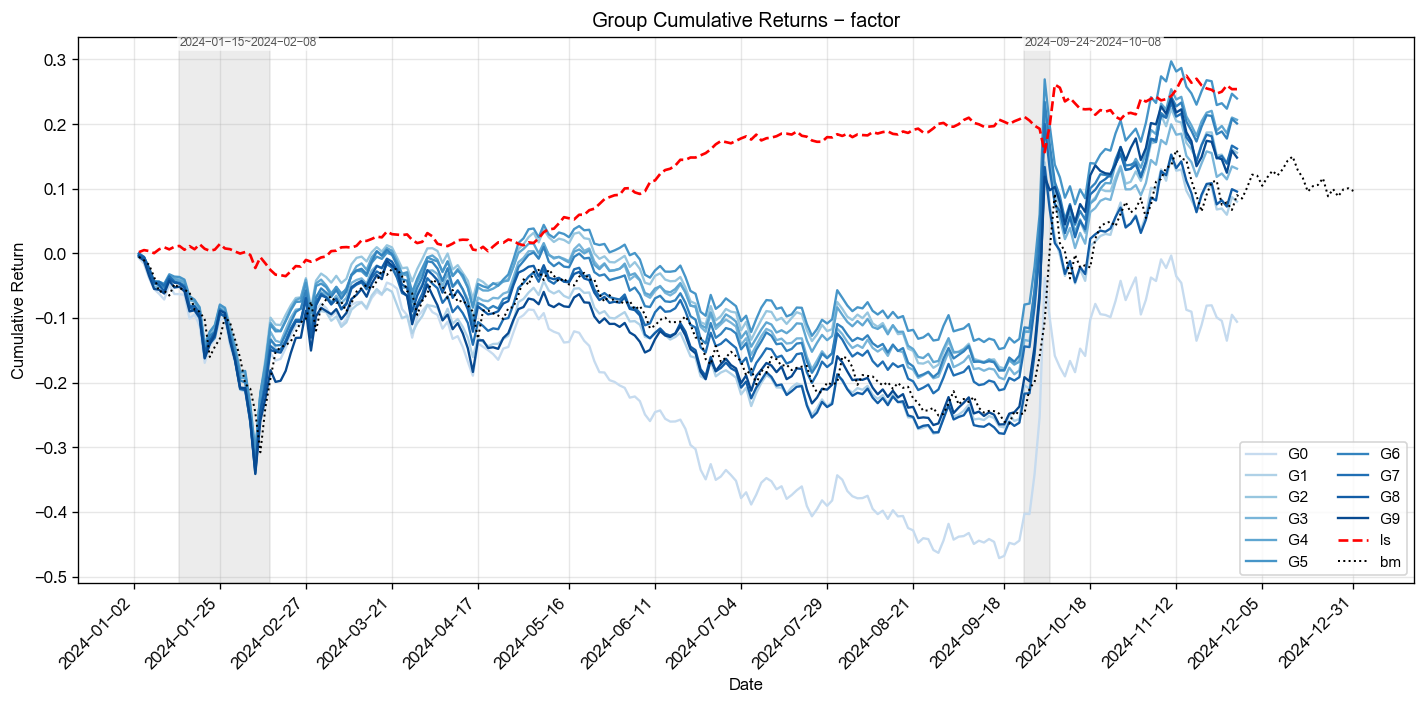
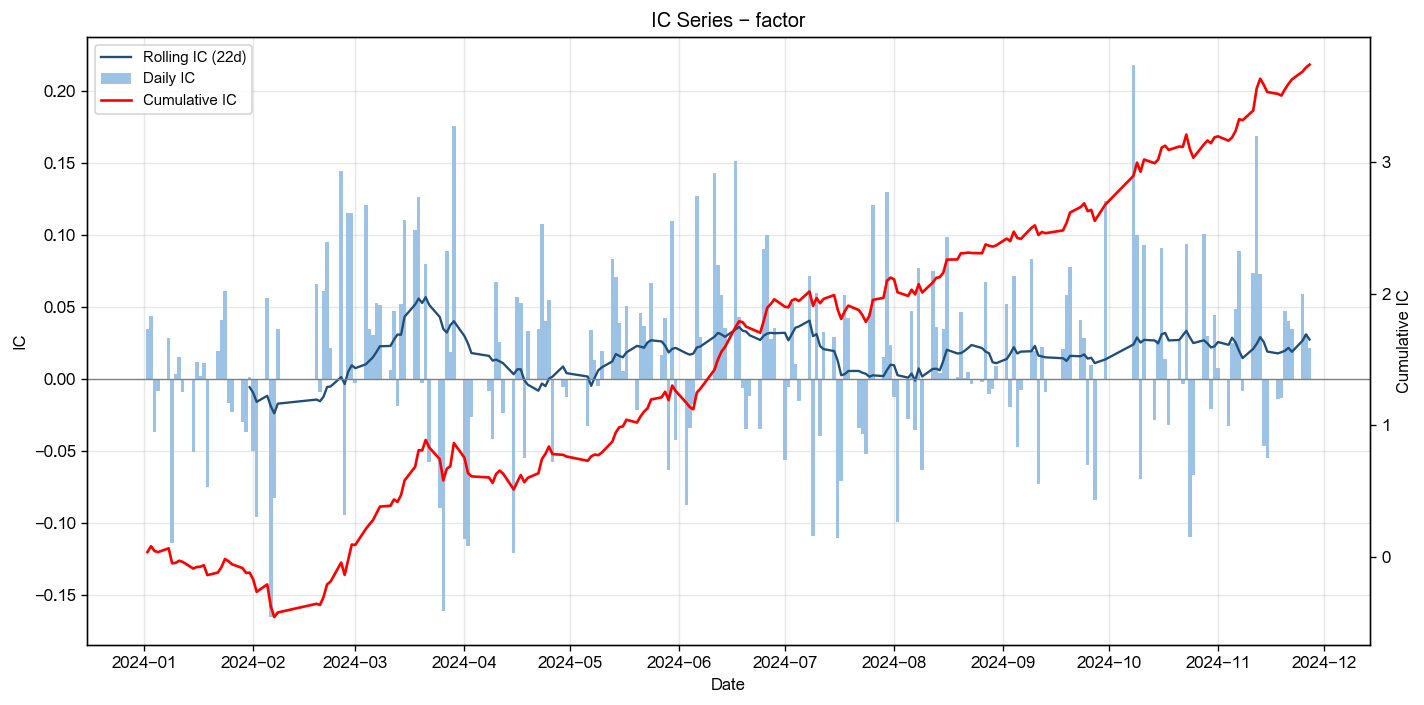
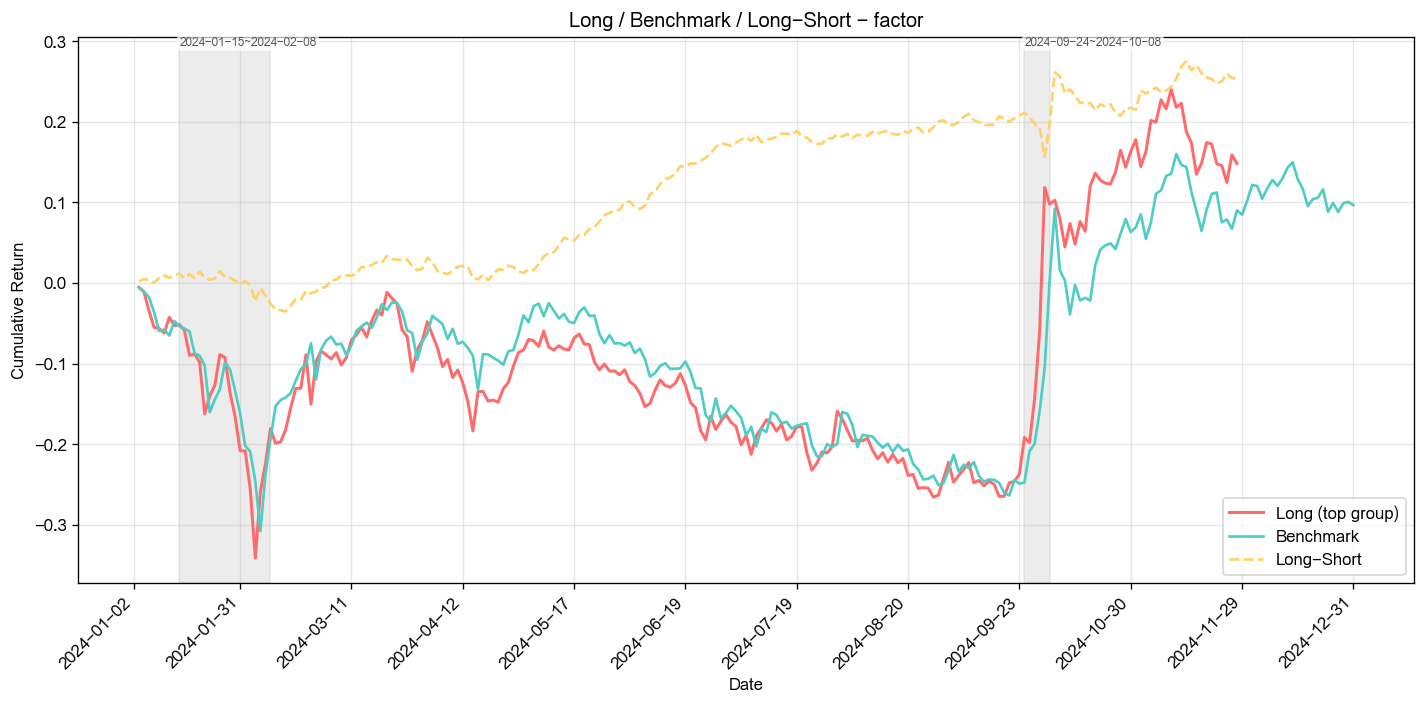
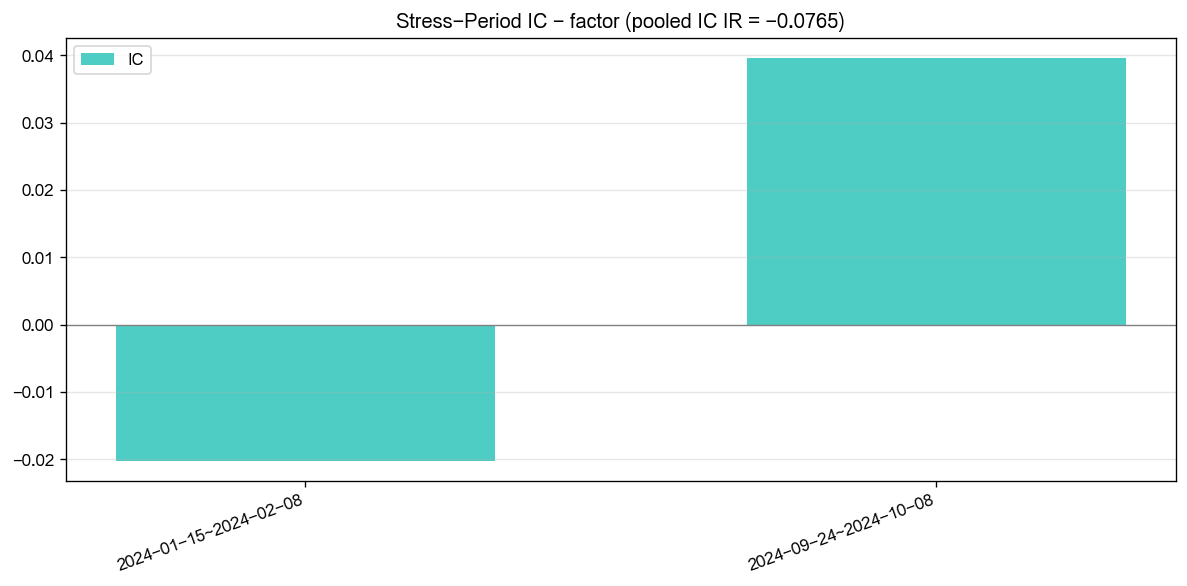
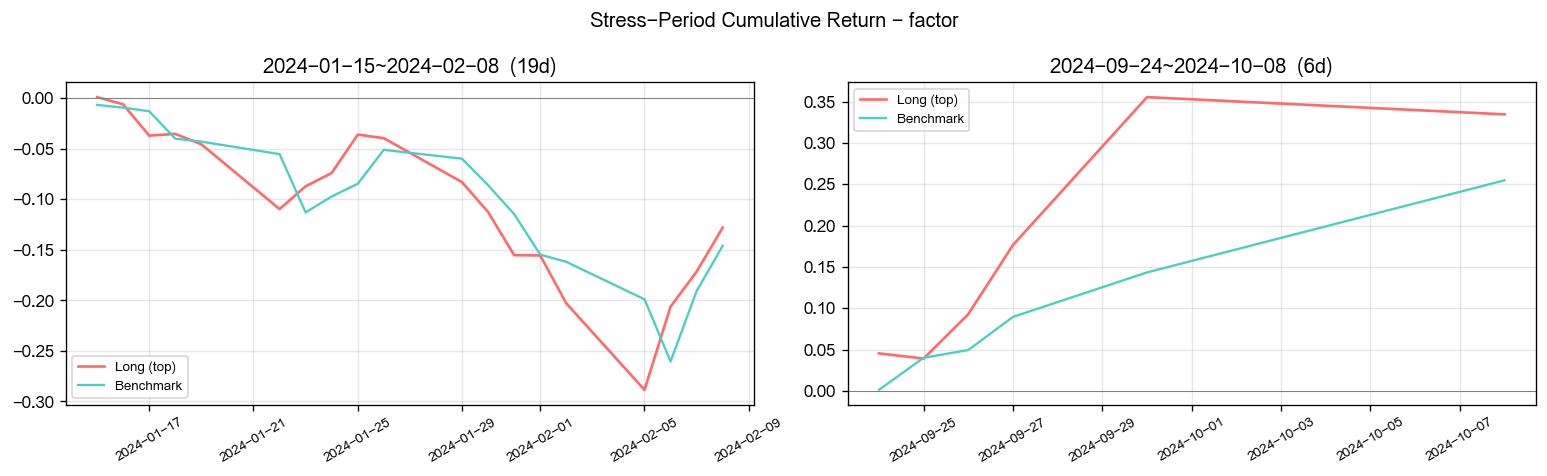

[2026-07-29 15:15:44] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-29 15:15:45] [warning  ] 返回的Outputs实例(size=35422582) 大于 64K, 将不会被缓存
[2026-07-29 15:15:45] [info     ] bigalpha_eval.v4 运行完成 [7.958s].
{'raw_factor':              date instrument    factor
0      2024-01-02  000006.SZ -0.046127
1      2024-01-02  000012.SZ -0.011679
2      2024-01-02  000016.SZ -0.099082
3      2024-01-02  000019.SZ -0.051235
4      2024-01-02  000025.SZ -0.105030
...           ...        ...       ...
241765 2024-12-31  688766.SH -0.160461
241766 2024-12-31  688776.SH -0.080560
241767 2024-12-31  688779.SH -0.046908
241768 2024-12-31  688789.SH -0.129478
241769 2024-12-31  688798.SH -0.124135

[241770 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.217036
1      2024-01-02  000012.SZ  0.318999
2      2024-01-02  000016.SZ -0.757798
3      2024-01-02  000019.SZ -0.505865
4      2024-01-02  000025.SZ -1.061873
...           ...        ...       ...
2419

In [1]:
import os

import dai
import numpy as np
import pandas as pd
import structlog
import torch

from transformer_train import (
    MODEL_PATH,
    FEATURE_COLS,
    PatchStockTransformer,
    load_model,
    pool,
    predict_scores,
    train_and_save,
)

logger = structlog.get_logger()


def main(datasources, start_date, end_date):
    """加载已训练模型，在平台测试区间分块生成日频score。"""
    table = datasources["bar1m"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"未找到模型文件 {MODEL_PATH}；请先执行 transformer_train.py，"
            "并将生成的 patch_ic_model.json 一并上传"
        )

    checkpoint = load_model(MODEL_PATH, map_location=device)
    if checkpoint.get("model_name") != "PatchStockTransformer":
        raise RuntimeError("模型文件类型与当前推理 Notebook 不一致")
    if checkpoint.get("feature_cols") != FEATURE_COLS:
        raise RuntimeError("模型文件中的字段列表与训练脚本不一致")

    stats = (
        np.asarray(checkpoint["mean"], np.float32),
        np.asarray(checkpoint["std"], np.float32),
    )
    model = PatchStockTransformer(**checkpoint["model_cfg"]).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    logger.info(
        "模型加载完成",
        path=MODEL_PATH,
        device=str(device),
        n_params=checkpoint.get("n_params"),
    )

    scores = predict_scores(
        model,
        table,
        start_date,
        end_date,
        pool(start_date, end_date),
        stats,
        device,
    )
    members = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    scores["date"] = pd.to_datetime(scores["date"]).dt.normalize()
    members["date"] = pd.to_datetime(members["date"]).dt.normalize()
    members["instrument"] = members["instrument"].astype(str)

    result = (
        pd.merge(scores, members, on=["date", "instrument"], how="inner")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["score"])
        .drop_duplicates(["date", "instrument"])
        [["date", "instrument", "score"]]
        .sort_values(["date", "instrument"], kind="mergesort")
        .reset_index(drop=True)
    )
    if result.empty:
        raise RuntimeError("模型输出与中证1000成分股合并后为空")
    logger.info(
        "分数构建完成",
        rows=len(result),
        days=result["date"].nunique(),
        instruments=result["instrument"].nunique(),
    )
    return result


if __name__ == "__main__":
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}

    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    score_data = main(datasources, start_date, end_date)

    print(score_data.head())
    print("总行数:", len(score_data))
    print("交易日数:", score_data["date"].nunique())
    print("股票数:", score_data["instrument"].nunique())
    print("重复数:", score_data.duplicated(["date", "instrument"]).sum())
    print("NaN数:", score_data["score"].isna().sum())

    print("每日股票数:")
    print(score_data.groupby("date")["instrument"].nunique().describe())

    print("分数分布:")
    print(score_data["score"].describe())


from bigmodule import M

evaluation = M.bigalpha_eval._latest(
    factor_data=score_data,
    show=True,
)
print(evaluation)